Valores encontrados na coluna fall:
fall
Found    44609
Fell      1107
Name: count, dtype: int64


,tipo,quantidade
0,Found,44609
1,Fell,1107


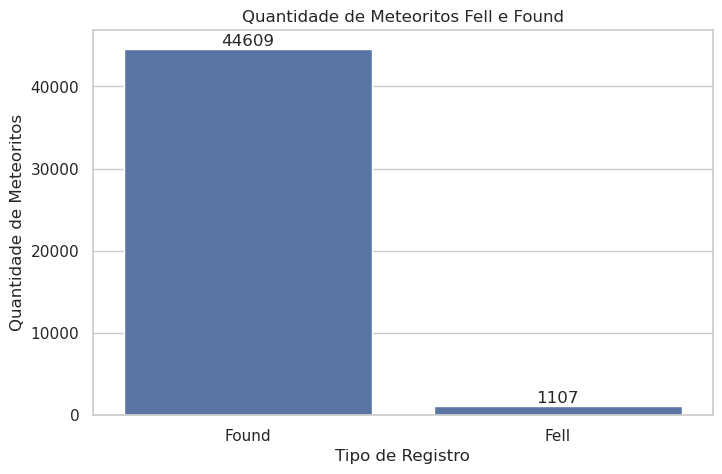

In [1]:
# Importa biblioteca principal para análise de dados
import pandas as pd

# Importa bibliotecas para criação de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Importa bibliotecas para limpar nomes das colunas
import re
import unicodedata

# Define o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Faz o Pandas mostrar todas as colunas
pd.set_option("display.max_columns", None)

# Faz o Pandas mostrar até 100 linhas
pd.set_option("display.max_rows", 100)

# Link direto do dataset da NASA
url = "https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv"

# Lê o dataset direto do link
df = pd.read_csv(url)

# Função para padronizar os nomes das colunas
def limpar_nome_coluna(nome):
    # Converte o nome da coluna para texto
    nome = str(nome)

    # Remove acentos, caso existam
    nome = unicodedata.normalize("NFKD", nome)
    nome = nome.encode("ascii", "ignore").decode("utf-8")

    # Converte para letras minúsculas
    nome = nome.lower()

    # Remove espaços no começo e no final
    nome = nome.strip()

    # Troca espaços e caracteres especiais por "_"
    nome = re.sub(r"[^a-z0-9]+", "_", nome)

    # Remove "_" do começo e do final
    nome = nome.strip("_")

    # Retorna o nome padronizado
    return nome

# Padroniza os nomes das colunas
df.columns = [limpar_nome_coluna(coluna) for coluna in df.columns]

# Verifica os valores existentes na coluna fall
print("Valores encontrados na coluna fall:")
print(df["fall"].value_counts())

# Conta quantos meteoritos são Found e quantos são Fell
contagem_fall = df["fall"].value_counts().reset_index()

# Renomeia as colunas para nomes mais amigáveis
contagem_fall.columns = ["tipo", "quantidade"]

# Mostra a tabela com a contagem
display(contagem_fall)

# Cria o tamanho da figura do gráfico
plt.figure(figsize=(8, 5))

# Cria o gráfico de barras
sns.barplot(
    data=contagem_fall,
    x="tipo",
    y="quantidade"
)

# Adiciona título ao gráfico
plt.title("Quantidade de Meteoritos Fell e Found")

# Adiciona nome ao eixo X
plt.xlabel("Tipo de Registro")

# Adiciona nome ao eixo Y
plt.ylabel("Quantidade de Meteoritos")

# Mostra os valores em cima de cada barra
for index, row in contagem_fall.iterrows():
    plt.text(
        index,
        row["quantidade"],
        row["quantidade"],
        ha="center",
        va="bottom"
    )

# Exibe o gráfico
plt.show()